## Регрессия: аппроксимация \(f(x,y) = \sin(x + 2y)\,e^{-(2x+y)^2}\)

Обучающая выборка: 20000 случайных точек \((x,y) \in [-10,10]^2\).  
Разбиение: train / val / test = 70% / 15% / 15%.

In [1]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

def target_fn(x, y):
    """sin(x + 2*y) * exp(-(2*x + y)^2)"""
    return np.sin(x + 2 * y) * np.exp(-((2 * x + y) ** 2))

n = 20_000
xy = np.random.uniform(-10.0, 10.0, size=(n, 2))
x_s, y_s = xy[:, 0], xy[:, 1]

z = target_fn(x_s, y_s).reshape(-1, 1)

X_train_val, X_test, y_train_val, y_test = train_test_split(
    xy, z, test_size=0.15, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.15 / 0.85, random_state=42
)

# Стандартизация данных(z-score)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)

X_train_t = torch.tensor(X_train_s, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
X_val_t = torch.tensor(X_val_s, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32)
X_test_t = torch.tensor(X_test_s, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32)

train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t), batch_size=256, shuffle=True
)

len(X_train), len(X_val), len(X_test)

(14000, 3000, 3000)

In [2]:
class MLPRegressor(nn.Module):
    def __init__(self, hidden=(128, 128, 64)):
        super().__init__()
        layers = []
        d_in = 2
        for h in hidden:
            layers += [nn.Linear(d_in, h), nn.ReLU()]
            d_in = h
        layers.append(nn.Linear(d_in, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Создаем сеть с набором слоев
model = MLPRegressor().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

n_epochs = 200
best_val = float("inf")
best_state = None

for epoch in range(1, n_epochs + 1):
    model.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        v_pred = model(X_val_t.to(device))
        val_loss = criterion(v_pred, y_val_t.to(device)).item()
    if val_loss < best_val:
        best_val = val_loss
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
    if epoch % 20 == 0 or epoch == 1:
        print(f"epoch {epoch:4d}  val_mse={val_loss:.6f}")

if best_state is not None:
    model.load_state_dict(best_state)
print("best val MSE:", best_val)

epoch    1  val_mse=0.015819
epoch   20  val_mse=0.001548
epoch   40  val_mse=0.000241
epoch   60  val_mse=0.000106
epoch   80  val_mse=0.000114
epoch  100  val_mse=0.000633
epoch  120  val_mse=0.000108
epoch  140  val_mse=0.000073
epoch  160  val_mse=0.000083
epoch  180  val_mse=0.000140
epoch  200  val_mse=0.000030
best val MSE: 2.8764074158971198e-05


### a) MSE на test

In [3]:
model.eval()
with torch.no_grad():
    test_pred = model(X_test_t.to(device)).cpu().numpy()

mse_test = np.mean((test_pred - y_test) ** 2)
print(f"Mean Squared Error (test): {mse_test:.6e}")

Mean Squared Error (test): 2.919306e-05


### b) Истинная поверхность и предсказание модели (контурные графики на сетке)

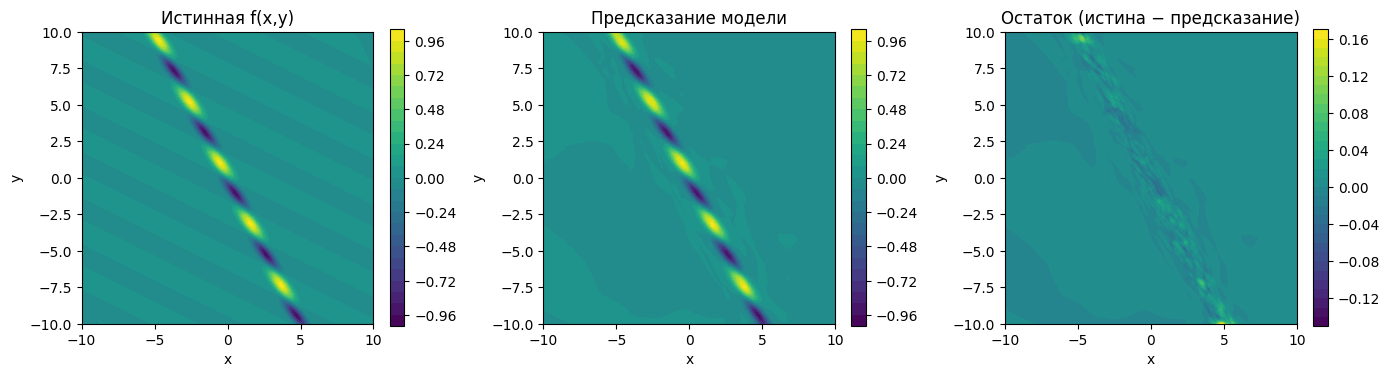

In [5]:
grid_n = 200
gx = np.linspace(-10, 10, grid_n)
gy = np.linspace(-10, 10, grid_n)
GX, GY = np.meshgrid(gx, gy)
Z_true = target_fn(GX, GY)

grid_xy = np.stack([GX.ravel(), GY.ravel()], axis=1)
grid_s = scaler.transform(grid_xy)
grid_t = torch.tensor(grid_s, dtype=torch.float32)

model.eval()
chunks = []
with torch.no_grad():
    for i in range(0, len(grid_t), 4096):
        chunks.append(model(grid_t[i : i + 4096].to(device)).cpu().numpy())
Z_pred = np.concatenate(chunks, axis=0).reshape(GX.shape)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
levels = 30
for ax, Z, title in zip(
    axes,
    [Z_true, Z_pred, Z_true - Z_pred],
    ["Истинная f(x,y)", "Предсказание модели", "Остаток (истина − предсказание)"],
):
    cs = ax.contourf(GX, GY, Z, levels=levels, cmap="viridis")
    plt.colorbar(cs, ax=ax, fraction=0.046)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(title)
    ax.set_aspect("equal")
plt.tight_layout()
plt.show()